# Seismometers: From Physics to Practice

**Learning Objectives:**
- Understand the physics of a seismometer as a damped harmonic oscillator
- Derive and interpret the instrument transfer function in the frequency domain
- Analyze extreme cases: when does a seismometer measure displacement, velocity, or acceleration?
- Connect the mathematical framework to poles-and-zeros representation
- Work with real seismic data and instrument response files using ObsPy
- Remove instrument response to recover true ground motion


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
})


---
# Part 1: The Physics of Seismometers

## 1.1 The Seismometer as a Damped Harmonic Oscillator

A seismometer measures ground motion by exploiting **inertia**: a suspended mass tends to remain stationary while the ground (and the instrument frame) moves beneath it. The relative displacement between mass and frame is our observable.

The simplest model consists of three elements:
- A **mass** $m$ (the inertial element)
- A **spring** with stiffness $k$ (the restoring force)
- A **dashpot** with damping coefficient $c$ (energy dissipation)

**Coordinate definitions:**
- $u(t)$: ground displacement (absolute frame — this is what we want to measure)
- $y(t)$: absolute displacement of the mass
- $x(t) = y(t) - u(t)$: displacement of the mass **relative to the frame**

The seismometer records $x(t)$, and our goal is to recover $u(t)$.


## 1.2 Equation of Motion

Newton's second law applied to the mass (in the absolute frame):

$$m\,\ddot{y} = -k\,x - c\,\dot{x}$$

Since $y = x + u$, we substitute $\ddot{y} = \ddot{x} + \ddot{u}$:

$$m(\ddot{x} + \ddot{u}) = -k\,x - c\,\dot{x}$$

Rearranging:

$$\boxed{m\,\ddot{x} + c\,\dot{x} + k\,x = -m\,\ddot{u}(t)}$$

This is the equation of a **forced damped harmonic oscillator**, where the forcing term is the ground acceleration $\ddot{u}(t)$.

### Standard form

Define the **natural angular frequency** and **damping ratio**:

$$\omega_0 = \sqrt{\frac{k}{m}}, \qquad h = \frac{c}{2m\omega_0}$$

The equation becomes:

$$\boxed{\ddot{x} + 2h\omega_0\,\dot{x} + \omega_0^2\,x = -\ddot{u}(t)}$$

- $\omega_0$ sets the characteristic frequency of the instrument
- $h$ controls how quickly free oscillations decay
- The natural period is $T_0 = 2\pi/\omega_0$


## 1.3 Frequency-Domain Analysis: The Transfer Function

Taking the Fourier transform of the equation of motion (using the convention $\dot{x}(t) \leftrightarrow i\omega\,X(\omega)$ and $\ddot{x}(t) \leftrightarrow -\omega^2 X(\omega)$):

$$(-\omega^2 + 2ih\omega_0\omega + \omega_0^2)\,X(\omega) = \omega^2\,U(\omega)$$

> Note: The right-hand side comes from $-\ddot{u}(t) \leftrightarrow -(-\omega^2)U(\omega) = \omega^2 U(\omega)$.

Solving for the **transfer function** $H(\omega) = X(\omega)/U(\omega)$:

$$\boxed{H(\omega) = \frac{\omega^2}{\omega_0^2 - \omega^2 + 2ih\omega_0\omega}}$$

This function completely characterizes the seismometer's response. It tells us:
- **Amplitude** $|H(\omega)|$: how much the output is amplified or attenuated at each frequency
- **Phase** $\arg[H(\omega)]$: the time delay (as a phase shift) at each frequency

### Key properties of $H(\omega)$

| Frequency | $|H(\omega)|$ | Physical meaning |
|-----------|---------------|------------------|
| $\omega \ll \omega_0$ | $\approx (\omega/\omega_0)^2$ | Output $\propto$ ground acceleration |
| $\omega = \omega_0$ | $= 1/(2h)$ | Resonance — amplification depends on damping |
| $\omega \gg \omega_0$ | $\approx 1$ | Output $\propto$ ground displacement |

Let's visualize this.


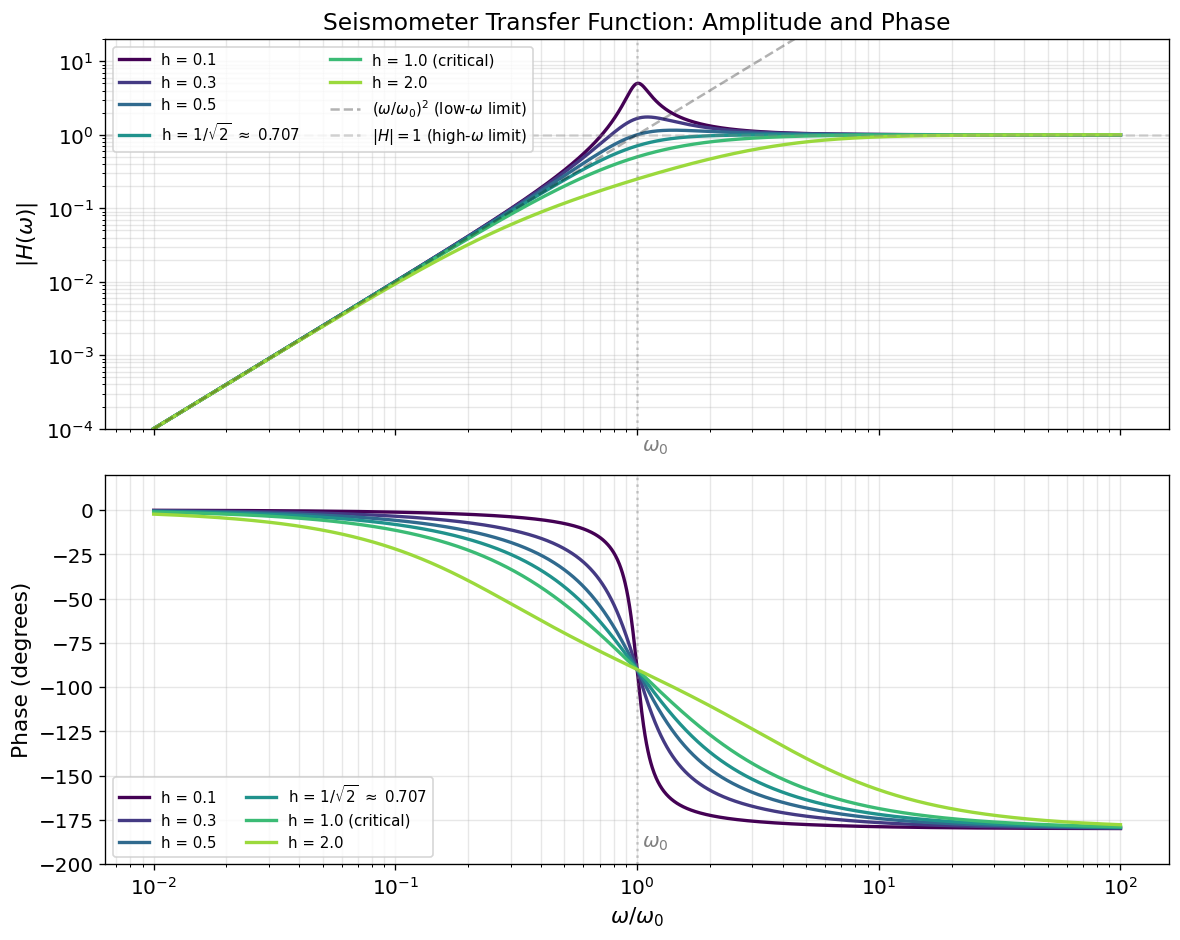

In [2]:
# Transfer function amplitude and phase for different damping ratios

omega_0 = 1.0  # normalized
omega = np.logspace(-2, 2, 2000) * omega_0
r = omega / omega_0  # frequency ratio

h_values = [0.1, 0.3, 0.5, 1/np.sqrt(2), 1.0, 2.0]
labels = ['h = 0.1', 'h = 0.3', 'h = 0.5', r'h = $1/\sqrt{2}$ $\approx$ 0.707', 'h = 1.0 (critical)', 'h = 2.0']
colors = plt.cm.viridis(np.linspace(0, 0.85, len(h_values)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for h, label, color in zip(h_values, labels, colors):
    H = r**2 / (1 - r**2 + 2j * h * r)
    ax1.loglog(r, np.abs(H), color=color, linewidth=2, label=label)
    ax2.semilogx(r, np.angle(H, deg=True), color=color, linewidth=2, label=label)

# Asymptotes
ax1.loglog(r, r**2, 'k--', alpha=0.3, linewidth=1.5, label=r'$(\omega/\omega_0)^2$ (low-$\omega$ limit)')
ax1.axhline(1, color='gray', linestyle='--', alpha=0.3, linewidth=1.5, label=r'$|H|=1$ (high-$\omega$ limit)')

ax1.axvline(1, color='gray', linestyle=':', alpha=0.4)
ax2.axvline(1, color='gray', linestyle=':', alpha=0.4)

ax1.set_ylabel(r'$|H(\omega)|$')
ax1.set_title('Seismometer Transfer Function: Amplitude and Phase')
ax1.legend(fontsize=9, ncol=2, loc='upper left')
ax1.set_ylim(1e-4, 20)
ax1.grid(True, alpha=0.3, which='both')
ax1.text(1.05, 0.5e-4, r'$\omega_0$', fontsize=12, color='gray')

ax2.set_xlabel(r'$\omega / \omega_0$')
ax2.set_ylabel('Phase (degrees)')
ax2.legend(fontsize=9, ncol=2, loc='lower left')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_ylim(-200, 20)
ax2.text(1.05, -190, r'$\omega_0$', fontsize=12, color='gray')

plt.tight_layout()
plt.show()


## 1.4 Extreme Cases

The transfer function reveals fundamentally different behavior depending on how the signal frequency compares to the instrument's natural frequency $\omega_0$.

### 1.4.1 Low-frequency limit: $\omega \ll \omega_0$ (Accelerometer regime)

When $\omega \ll \omega_0$, the denominator is dominated by $\omega_0^2$:

$$H(\omega) \approx \frac{\omega^2}{\omega_0^2}$$

Therefore:

$$X(\omega) \approx \frac{\omega^2}{\omega_0^2}\,U(\omega) = \frac{1}{\omega_0^2}\left[-(-\omega^2 U(\omega))\right] = -\frac{1}{\omega_0^2}\,\ddot{U}(\omega)$$

In the time domain:

$$\boxed{x(t) \approx -\frac{\ddot{u}(t)}{\omega_0^2}} \qquad (\omega \ll \omega_0)$$

**The output is proportional to ground acceleration.** This is the principle behind accelerometers (strong-motion sensors), which have a high natural frequency $\omega_0$ so that earthquake frequencies fall well below it.

### 1.4.2 High-frequency limit: $\omega \gg \omega_0$ (Displacement regime)

When $\omega \gg \omega_0$, the $-\omega^2$ term dominates the denominator:

$$H(\omega) \approx \frac{\omega^2}{-\omega^2} = -1$$

Therefore:

$$\boxed{x(t) \approx -u(t)} \qquad (\omega \gg \omega_0)$$

**The output directly tracks ground displacement** (with a sign flip). This is the principle behind long-period seismometers: by making $\omega_0$ very small (long natural period), the instrument measures displacement for all signals above the natural frequency.

### 1.4.3 Near resonance: $\omega \approx \omega_0$

At $\omega = \omega_0$:

$$H(\omega_0) = \frac{\omega_0^2}{2ih\omega_0^2} = \frac{1}{2ih} = \frac{-i}{2h}$$

$$|H(\omega_0)| = \frac{1}{2h}$$

| Damping $h$ | $|H(\omega_0)|$ | Behavior |
|-------------|-----------------|----------|
| 0 | $\infty$ | Undamped resonance — unphysical |
| 0.1 | 5.0 | Strong amplification near $\omega_0$ |
| $1/\sqrt{2}$ | $\approx 0.707$ | Maximally flat (Butterworth), smoothest transition between regimes |
| 1.0 | 0.5 | Critically damped — no overshoot in impulse response |
| 2.0 | 0.25 | Overdamped — sluggish response |

Most seismometers use $h \approx 0.707$ for the flattest possible amplitude response.


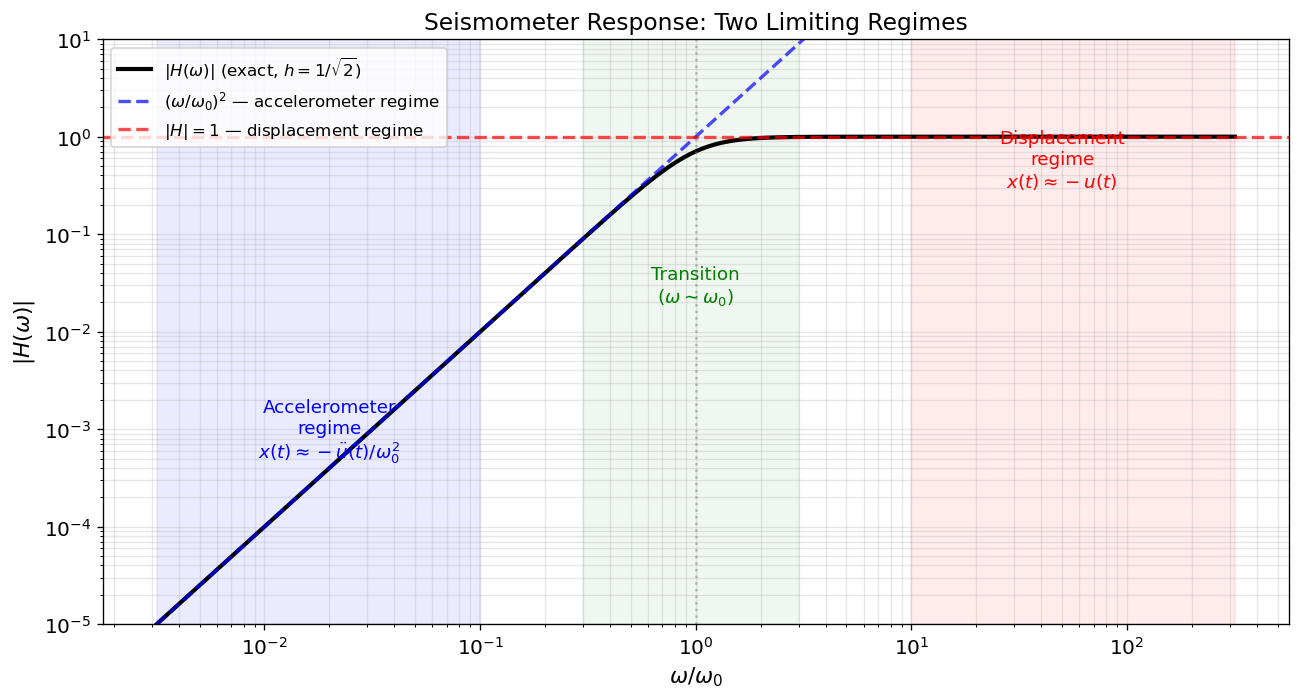

In [3]:
# Visualize extreme cases and the transition between regimes

h = 1 / np.sqrt(2)
r = np.logspace(-2.5, 2.5, 3000)
H = r**2 / (1 - r**2 + 2j * h * r)

fig, ax = plt.subplots(figsize=(11, 6))

# Full response
ax.loglog(r, np.abs(H), 'k-', linewidth=2.5, label=r'$|H(\omega)|$ (exact, $h = 1/\sqrt{2}$)')

# Low-frequency asymptote
ax.loglog(r, r**2, 'b--', linewidth=2, alpha=0.7,
          label=r'$(\omega/\omega_0)^2$ — accelerometer regime')

# High-frequency asymptote
ax.axhline(1, color='r', linestyle='--', linewidth=2, alpha=0.7,
           label=r'$|H| = 1$ — displacement regime')

# Shaded regions
ax.axvspan(r[0], 0.1, alpha=0.08, color='blue')
ax.axvspan(10, r[-1], alpha=0.08, color='red')
ax.axvspan(0.3, 3, alpha=0.06, color='green')

# Annotations
ax.text(0.02, 5e-4, 'Accelerometer\nregime\n' + r'$x(t) \approx -\ddot{u}(t)/\omega_0^2$',
        fontsize=11, color='blue', ha='center')
ax.text(50, 0.3, 'Displacement\nregime\n' + r'$x(t) \approx -u(t)$',
        fontsize=11, color='red', ha='center')
ax.text(1, 0.02, 'Transition\n' + r'($\omega \sim \omega_0$)',
        fontsize=11, color='green', ha='center')

ax.axvline(1, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel(r'$\omega / \omega_0$')
ax.set_ylabel(r'$|H(\omega)|$')
ax.set_title('Seismometer Response: Two Limiting Regimes')
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(1e-5, 10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 1.5 Effect of Damping: Time-Domain Impulse Response

The damping ratio $h$ controls the **transient behavior** of the seismometer. When the ground experiences a sudden impulse, the seismometer's free oscillation decays at a rate governed by $h$.

The homogeneous solution (free vibration) of $\ddot{x} + 2h\omega_0\dot{x} + \omega_0^2 x = 0$ is:

$$x(t) = A\,e^{-h\omega_0 t}\sin(\omega_d t + \phi)$$

where $\omega_d = \omega_0\sqrt{1 - h^2}$ is the **damped natural frequency** (for $h < 1$).

- **Underdamped** ($h < 1$): oscillates with exponentially decaying amplitude
- **Critically damped** ($h = 1$): fastest return to zero without oscillation
- **Overdamped** ($h > 1$): slow, non-oscillatory return to zero


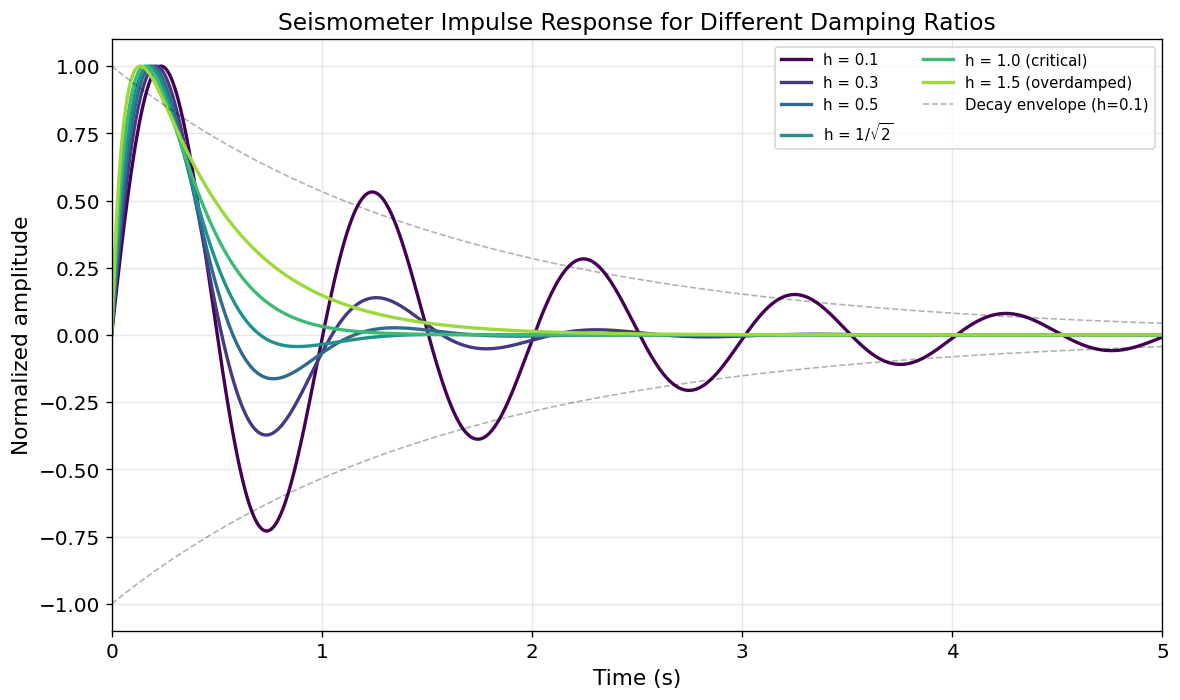

In [4]:
# Impulse response in the time domain for different damping ratios

omega_0 = 2 * np.pi  # natural frequency (1 Hz natural period)
t = np.linspace(0, 5, 2000)

h_values = [0.1, 0.3, 0.5, 1/np.sqrt(2), 1.0, 1.5]
labels = ['h = 0.1', 'h = 0.3', 'h = 0.5', r'h = 1/$\sqrt{2}$', 'h = 1.0 (critical)', 'h = 1.5 (overdamped)']
colors = plt.cm.viridis(np.linspace(0, 0.85, len(h_values)))

fig, ax = plt.subplots(figsize=(10, 6))

for h, label, color in zip(h_values, labels, colors):
    if h < 1:
        omega_d = omega_0 * np.sqrt(1 - h**2)
        x = np.exp(-h * omega_0 * t) * np.sin(omega_d * t)
    elif h == 1:
        x = omega_0 * t * np.exp(-omega_0 * t)
    else:
        r1 = -h * omega_0 + omega_0 * np.sqrt(h**2 - 1)
        r2 = -h * omega_0 - omega_0 * np.sqrt(h**2 - 1)
        x = (np.exp(r1 * t) - np.exp(r2 * t)) / (r1 - r2)

    # Normalize for comparison
    x = x / np.max(np.abs(x)) if np.max(np.abs(x)) > 0 else x
    ax.plot(t, x, color=color, linewidth=2, label=label)

# Envelope for h=0.1
h_env = 0.1
envelope = np.exp(-h_env * omega_0 * t)
ax.plot(t, envelope, 'k--', alpha=0.3, linewidth=1, label='Decay envelope (h=0.1)')
ax.plot(t, -envelope, 'k--', alpha=0.3, linewidth=1)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized amplitude')
ax.set_title('Seismometer Impulse Response for Different Damping Ratios')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()


## 1.6 Poles and Zeros Representation

The transfer function can be expressed using the **Laplace variable** $s = i\omega$:

$$H(s) = \frac{-s^2}{s^2 + 2h\omega_0 s + \omega_0^2} = \frac{-s^2}{(s - p_1)(s - p_2)}$$

where the **poles** are:

$$p_{1,2} = -h\omega_0 \pm \omega_0\sqrt{h^2 - 1}$$

and the **zeros** are at $z_1 = z_2 = 0$ (double zero at the origin).

**Physical interpretation:**
- **Zeros at the origin**: the seismometer has zero sensitivity to static (DC) displacement — it cannot record a permanent offset
- **Poles**: determine the natural oscillation frequency and decay rate. For underdamped systems ($h < 1$), the poles are complex conjugates, encoding both the oscillation frequency and the decay rate.

This pole-zero representation is **exactly how real instrument responses are stored** in seismic metadata (StationXML, RESP files). We'll see this in Part 2.


## 1.7 Simulation: What Different Instruments Record

Let's see the practical consequence of $\omega_0$. We'll create a synthetic ground velocity pulse and pass it through seismometers with different natural periods to see how each one "sees" the same ground motion.

We simulate three instrument types:
- **Short-period** ($T_0 = 1$ s): primarily senses high-frequency motion
- **Broadband** ($T_0 = 120$ s): captures both body waves and surface waves
- **Accelerometer** ($T_0 = 0.01$ s, $\omega_0$ very high): output $\propto$ ground acceleration at seismic frequencies


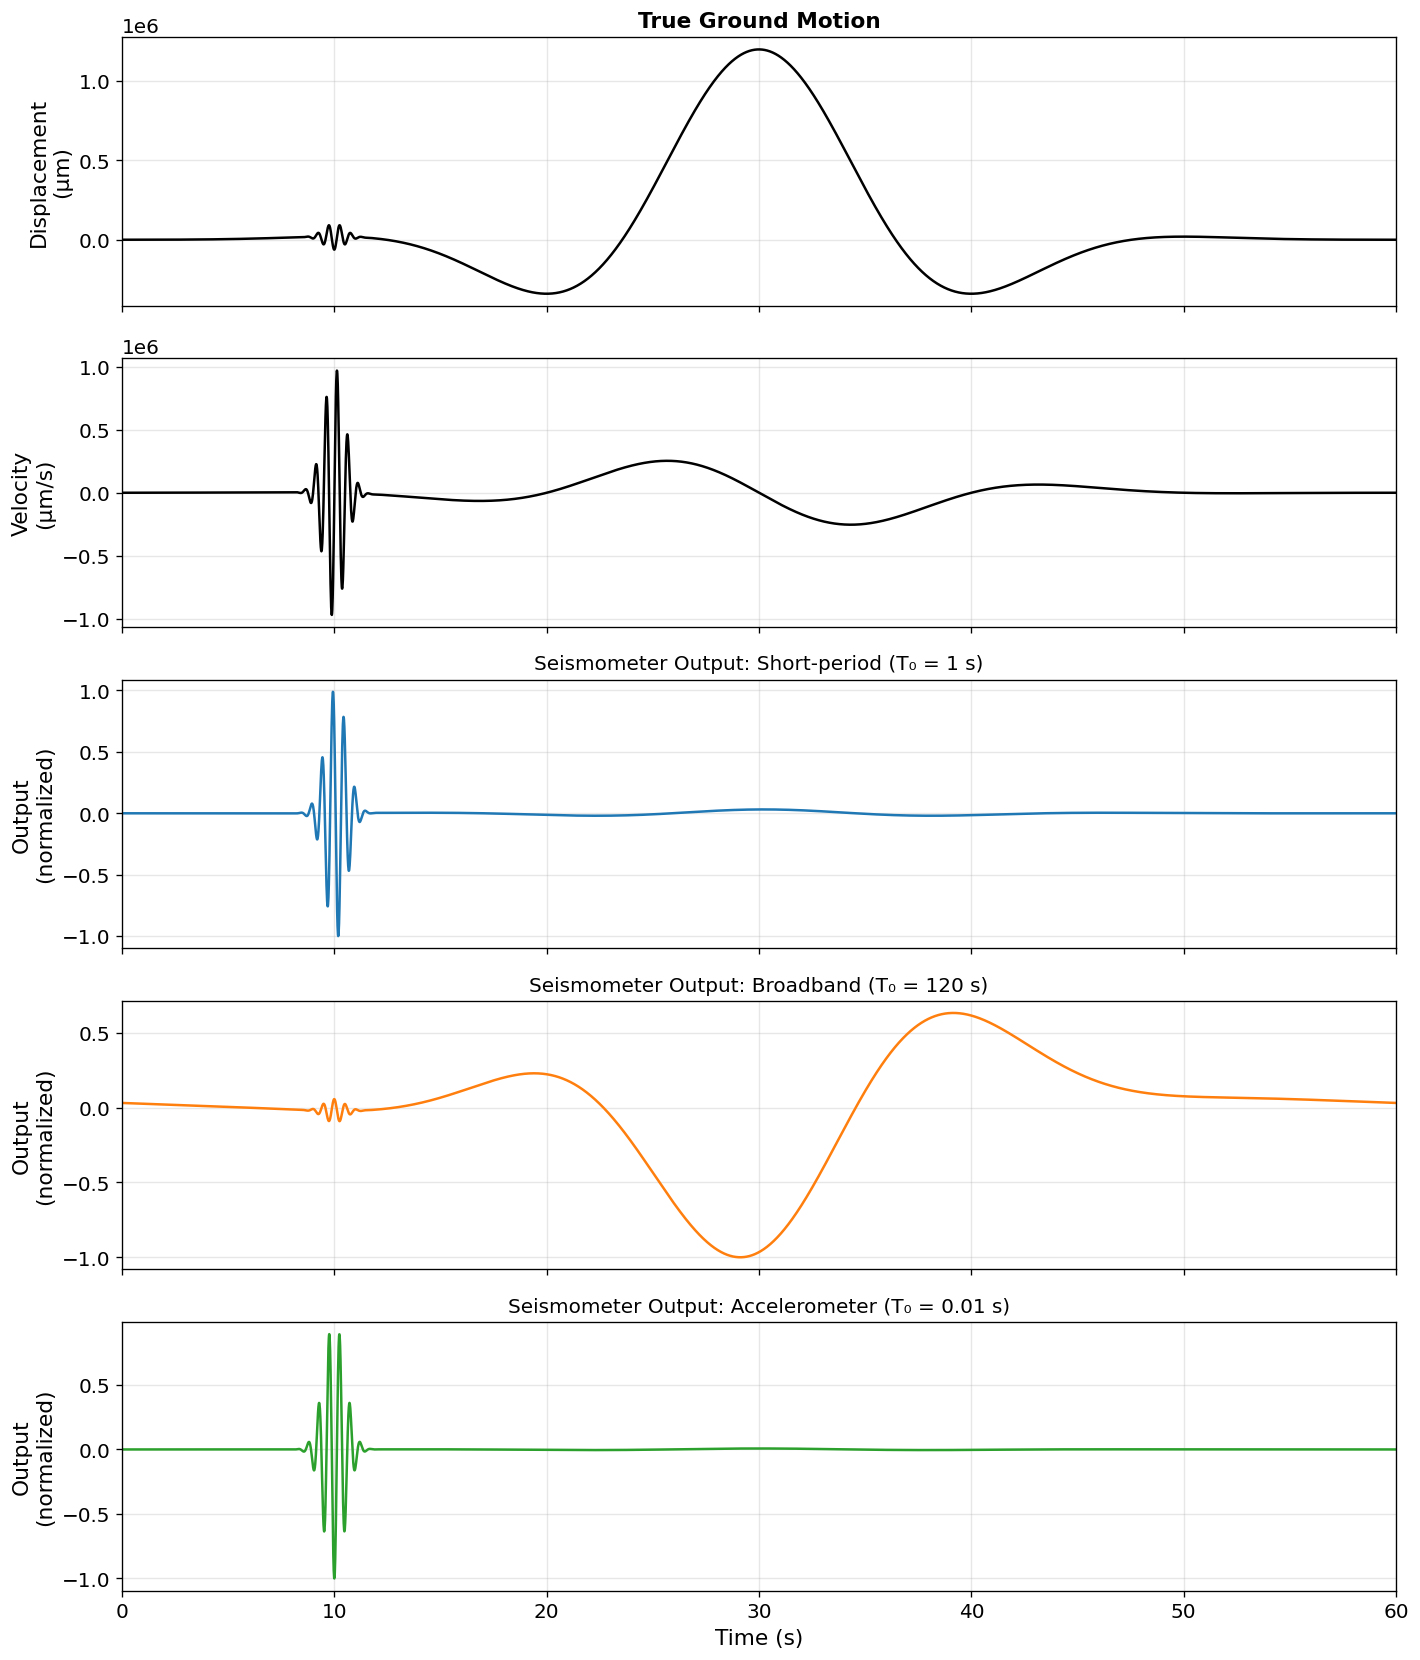

In [5]:
# Simulate different seismometer types recording the same ground motion

# Create a synthetic ground displacement: a Gaussian pulse + longer period oscillation
dt = 0.01
t = np.arange(0, 60, dt)
freq = np.fft.rfftfreq(len(t), dt)
omega = 2 * np.pi * freq

# Synthetic ground velocity: mix of a short pulse and a long-period wave
ground_vel = (np.exp(-((t - 10)**2) / (2 * 0.5**2)) * np.sin(2 * np.pi * 2 * (t - 10))
              + 0.3 * np.sin(2 * np.pi * 0.05 * t) * np.exp(-((t - 30)**2) / (2 * 8**2)))

# Ground displacement (integral of velocity)
ground_disp = np.cumsum(ground_vel) * dt

# Ground acceleration (derivative of velocity)
ground_acc = np.gradient(ground_vel, dt)

# FFT of ground displacement
U = np.fft.rfft(ground_disp)

# Three instrument types
instruments = [
    {'name': 'Short-period (T₀ = 1 s)', 'T0': 1.0, 'h': 0.707, 'color': 'C0'},
    {'name': 'Broadband (T₀ = 120 s)', 'T0': 120.0, 'h': 0.707, 'color': 'C1'},
    {'name': 'Accelerometer (T₀ = 0.01 s)', 'T0': 0.01, 'h': 0.707, 'color': 'C2'},
]

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

# Plot ground truth
axes[0].plot(t, ground_disp * 1e6, 'k', linewidth=1.5)
axes[0].set_ylabel('Displacement\n(μm)')
axes[0].set_title('True Ground Motion', fontsize=13, fontweight='bold')

axes[1].plot(t, ground_vel * 1e6, 'k', linewidth=1.5)
axes[1].set_ylabel('Velocity\n(μm/s)')

for idx, inst in enumerate(instruments):
    omega_0 = 2 * np.pi / inst['T0']
    h = inst['h']

    # Transfer function (skip DC)
    H = np.zeros_like(omega, dtype=complex)
    mask = omega > 0
    r = omega[mask] / omega_0
    H[mask] = r**2 / (1 - r**2 + 2j * h * r)

    # Seismometer output (relative displacement)
    X = H * U
    x = np.fft.irfft(X, n=len(t))

    axes[idx + 2].plot(t, x / np.max(np.abs(x)), color=inst['color'], linewidth=1.5)
    axes[idx + 2].set_ylabel(f'Output\n(normalized)')
    axes[idx + 2].set_title(f'Seismometer Output: {inst["name"]}', fontsize=12)

axes[-1].set_xlabel('Time (s)')
axes[-1].set_xlim(0, 60)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Key observations from the simulation:**

1. The **short-period** instrument only records the high-frequency pulse; the long-period surface wave is invisible.
2. The **broadband** instrument faithfully captures both the high-frequency body wave and the long-period oscillation.
3. The **accelerometer** output resembles the time derivative of velocity (i.e., acceleration), emphasizing the sharpest transients.

This is why broadband seismometers revolutionized seismology — a single instrument covers the full range of seismic signals from ~0.01 Hz to ~50 Hz.


---
# Part 2: Working with Real Data

We'll use ObsPy to download real earthquake data and explore instrument response files in detail.

**Event:** 2011 Tohoku-Oki earthquake ($M_w$ 9.1, Japan)
- Origin time: 2011-03-11 05:46:24 UTC
- One of the best-recorded great earthquakes in history

**Station:** IU.ANMO (Albuquerque, New Mexico)
- Global Seismographic Network station
- Broadband seismometer
- Epicentral distance $\approx$ 77°

We start the data window **700 s after the origin time**, just before the P-wave arrival at this distance, to focus on the seismic signal.


In [6]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client

client = Client("IRIS")

# 2011 Tohoku earthquake origin time
origin = UTCDateTime("2011-03-11T05:46:24")

# Start 700s after origin (just before P arrival at ~77°) and record for 1 hour
t_start = origin + 700
t_end = t_start + 3600

# Download broadband vertical data
st = client.get_waveforms("IU", "ANMO", "00", "BHZ",
                          t_start, t_end)

# Download station metadata including full instrument response
inv = client.get_stations(network="IU", station="ANMO", location="00",
                          channel="BHZ", starttime=t_start, endtime=t_end,
                          level="response")

print("Waveform data:")
print(st)
print()
print("Station inventory:")
print(inv)


Waveform data:
1 Trace(s) in Stream:
IU.ANMO.00.BHZ | 2011-03-11T05:58:04.019538Z - 2011-03-11T06:58:03.969538Z | 20.0 Hz, 72000 samples

Station inventory:
Inventory created at 2026-03-19T06:40:30.778500Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=2011-03-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			IU
		Stations (1):
			IU.ANMO (Albuquerque, New Mexico, USA)
		Channels (1):
			IU.ANMO.00.BHZ


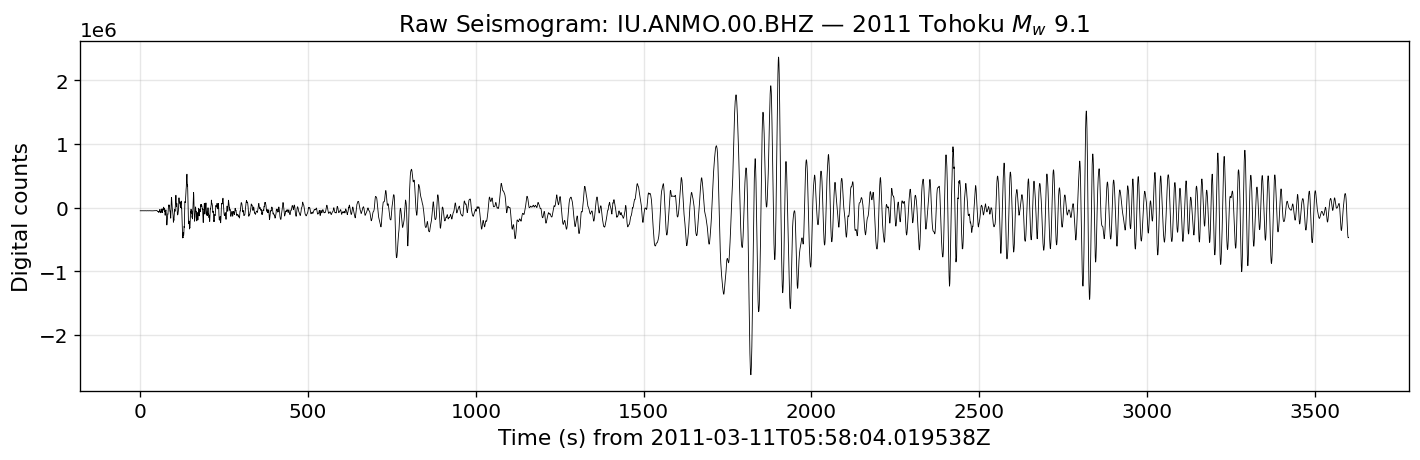

Sampling rate: 20.0 Hz
Number of samples: 72000
Duration: 3600.0 s


In [7]:
# Plot the raw seismogram (digital counts)

tr = st[0]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tr.times(), tr.data, 'k', linewidth=0.5)
ax.set_xlabel(f'Time (s) from {tr.stats.starttime}')
ax.set_ylabel('Digital counts')
ax.set_title(f'Raw Seismogram: {tr.id} — 2011 Tohoku $M_w$ 9.1')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sampling rate: {tr.stats.sampling_rate} Hz")
print(f"Number of samples: {tr.stats.npts}")
print(f"Duration: {tr.stats.npts / tr.stats.sampling_rate:.1f} s")


## 2.1 Anatomy of an Instrument Response File

The **instrument response** describes the complete transfer function from ground motion to digital counts recorded on disk. It is a chain of multiple **stages**:

| Stage | Component | What it does | Key parameters |
|-------|-----------|-------------|----------------|
| 1 | **Sensor** (seismometer) | Converts ground motion to voltage | Poles, zeros, normalization |
| 2 | **Digitizer** (ADC) | Converts voltage to digital counts | Gain (counts/V) |
| 3+ | **Digital filters** (FIR) | Anti-alias filtering, decimation | Filter coefficients |

The **total response** is the product of all stages:

$$T(\omega) = \underbrace{S(\omega)}_{\text{sensor}} \times \underbrace{G_{\text{ADC}}}_{\text{digitizer}} \times \underbrace{D(\omega)}_{\text{digital filters}}$$

### The Sensor Stage: Poles and Zeros

The sensor's analog response is represented as:

$$S(s) = A_0 \cdot G_s \cdot \frac{\prod_{k}(s - z_k)}{\prod_{k}(s - p_k)}$$

where:
- $A_0$ = normalization factor (chosen so that $|S| = 1$ at a reference frequency)
- $G_s$ = sensor gain (V·s/m for velocity output)
- $z_k$ = zeros of the transfer function
- $p_k$ = poles of the transfer function
- $s = i\omega$ (Laplace variable evaluated on the imaginary axis)

This is exactly the pole-zero representation we derived in Section 1.6!

Let's examine the actual response of our station.


In [8]:
# Extract and examine the response stages

response = inv.get_response("IU.ANMO.00.BHZ", origin)

print("=" * 70)
print("FULL INSTRUMENT RESPONSE")
print("=" * 70)
print(response)


FULL INSTRUMENT RESPONSE
Channel Response
	From m/s (Velocity in Meters Per Second) to counts (Digital Counts)
	Overall Sensitivity: 3.27511e+09 defined at 0.020 Hz
	3 stages:
		Stage 1: PolesZerosResponseStage from m/s to V, gain: 1952.1
		Stage 2: CoefficientsTypeResponseStage from V to counts, gain: 1.67772e+06
		Stage 3: CoefficientsTypeResponseStage from counts to counts, gain: 1


In [9]:
# Look at the sensor stage (Stage 1) in detail
# This contains the poles and zeros

stage1 = response.response_stages[0]

print("STAGE 1: SENSOR (Analog)")
print("=" * 50)
print(f"Description: {stage1.description}")
print(f"Input units:  {stage1.input_units}")
print(f"Output units: {stage1.output_units}")
print(f"Stage gain:   {stage1.stage_gain:.6e} {stage1.output_units}/{stage1.input_units}")
print(f"Stage gain frequency: {stage1.stage_gain_frequency} Hz")
print()

# Poles and zeros
pz = stage1
print(f"Normalization factor A₀: {pz.normalization_factor:.6e}")
print(f"Normalization frequency: {pz.normalization_frequency} Hz")
print()
print(f"Number of zeros: {len(pz.zeros)}")
print("Zeros:")
for i, z in enumerate(pz.zeros):
    print(f"  z{i}: {z.real:+.6e} {z.imag:+.6e}j")
print()
print(f"Number of poles: {len(pz.poles)}")
print("Poles:")
for i, p in enumerate(pz.poles):
    freq_hz = np.abs(p) / (2 * np.pi)
    print(f"  p{i}: {p.real:+.6e} {p.imag:+.6e}j   (|p|/2π = {freq_hz:.4f} Hz)")


STAGE 1: SENSOR (Analog)
Description: None
Input units:  m/s
Output units: V
Stage gain:   1.952100e+03 V/m/s
Stage gain frequency: 0.02 Hz

Normalization factor A₀: 8.629850e+04
Normalization frequency: 0.02 Hz

Number of zeros: 2
Zeros:
  z0: +0.000000e+00 +0.000000e+00j
  z1: +0.000000e+00 +0.000000e+00j

Number of poles: 5
Poles:
  p0: -4.800400e-03 +0.000000e+00j   (|p|/2π = 0.0008 Hz)
  p1: -7.393730e-02 +0.000000e+00j   (|p|/2π = 0.0118 Hz)
  p2: -2.271210e+01 -2.710650e+01j   (|p|/2π = 5.6283 Hz)
  p3: -2.271210e+01 +2.710650e+01j   (|p|/2π = 5.6283 Hz)
  p4: -5.943130e+01 +0.000000e+00j   (|p|/2π = 9.4588 Hz)


### Interpreting the Poles and Zeros

Compare what you see above with our theoretical model:

**Theoretical (simple seismometer):**
- 2 zeros at $s = 0$ → sensitivity goes to zero at DC
- 2 complex conjugate poles at $s = -h\omega_0 \pm i\omega_0\sqrt{1-h^2}$

**Real instrument (broadband):**
- You should see zeros at or near $s = 0$ (same physical meaning — no DC sensitivity)
- Multiple poles — the real instrument has a more complex transfer function due to the **force-feedback electronics** that extend the flat response band
- Additional poles and zeros shape the response at the high-frequency end

The extra complexity comes from the electronic feedback loop that gives broadband sensors their remarkably flat velocity response from ~0.008 Hz (120 s period) to the Nyquist frequency.


/Users/weiqiang/.local/miniconda3/lib/python3.12/site-packages/obspy/core/inventory/response.py:2318: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower center", ncol=3, fontsize='small')


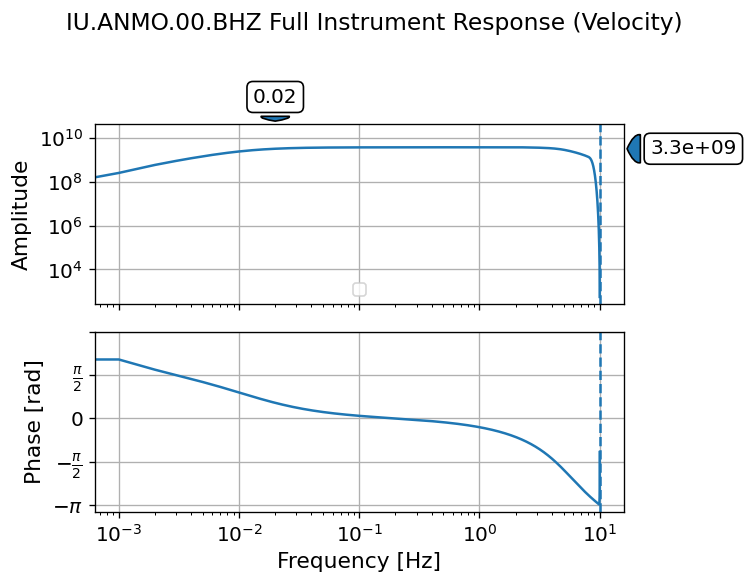

In [10]:
# Plot the full instrument response (all stages combined)

fig = response.plot(min_freq=0.001, output="VEL", show=False)
fig.suptitle("IU.ANMO.00.BHZ Full Instrument Response (Velocity)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


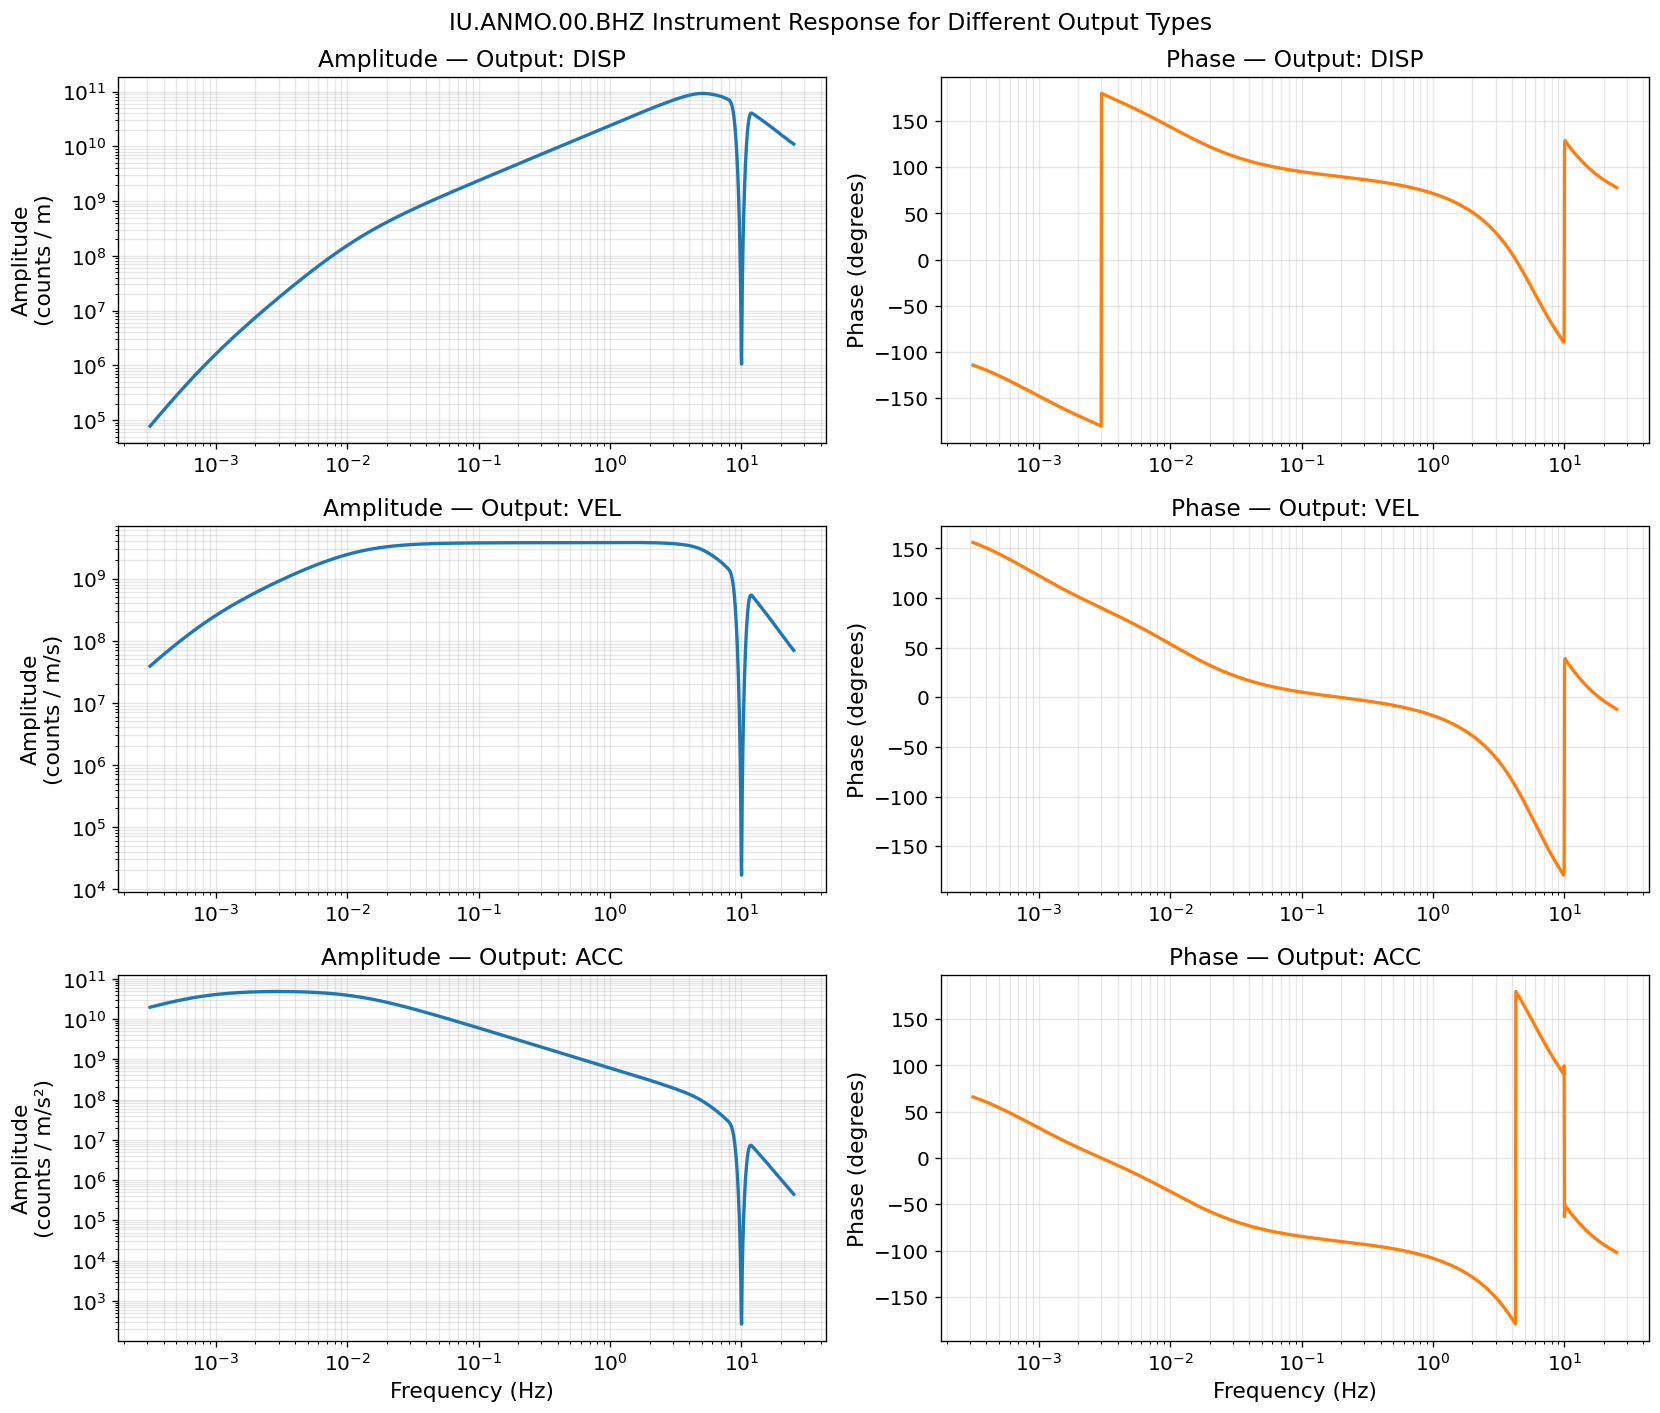

In [11]:
# Plot responses for all three output types: displacement, velocity, acceleration

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, (output, title) in enumerate([("DISP", "Displacement (m)"),
                                         ("VEL", "Velocity (m/s)"),
                                         ("ACC", "Acceleration (m/s²)")]):
    # Compute response manually for more control
    freqs = np.logspace(-3.5, np.log10(25), 2000)
    resp_complex = response.get_evalresp_response_for_frequencies(
        freqs, output=output)

    axes[idx, 0].loglog(freqs, np.abs(resp_complex), 'C0', linewidth=2)
    axes[idx, 0].set_ylabel(f'Amplitude\n(counts / {title.split("(")[1]}')
    axes[idx, 0].set_title(f'Amplitude — Output: {output}')
    axes[idx, 0].grid(True, alpha=0.3, which='both')

    axes[idx, 1].semilogx(freqs, np.angle(resp_complex, deg=True), 'C1', linewidth=2)
    axes[idx, 1].set_ylabel('Phase (degrees)')
    axes[idx, 1].set_title(f'Phase — Output: {output}')
    axes[idx, 1].grid(True, alpha=0.3, which='both')

for ax in axes[-1]:
    ax.set_xlabel('Frequency (Hz)')

plt.suptitle('IU.ANMO.00.BHZ Instrument Response for Different Output Types', fontsize=14)
plt.tight_layout()
plt.show()


### Connecting the response plots to theory

Notice the key differences between the three output types:

- **Displacement response**: amplitude grows as $\sim \omega^3$ at low frequencies (two zeros from the mechanical system + one from the velocity transducer), flat in the passband, then rolls off
- **Velocity response**: the classic "flat" broadband response — flat from ~0.008 Hz to ~8 Hz, corresponding to the $T_0 = 120$ s corner period
- **Acceleration response**: flat at low frequencies, grows through the passband (complementary to displacement)

The **velocity response** shows exactly the behavior we derived in Section 1.4: flat above the corner frequency (where $|H| \approx 1$) and rolling off below it.

### Why does the response drop sharply near 10 Hz?

You may notice a steep drop in the amplitude response near **10 Hz**. This is **not** a sensor limitation — the analog seismometer itself has sensitivity well beyond 10 Hz.

The drop comes from the **digital anti-aliasing filter** in the datalogger. The BHZ channel at this station has a **sampling rate of 20 samples per second**, giving a **Nyquist frequency of 10 Hz**. The Nyquist-Shannon sampling theorem requires that all energy above the Nyquist frequency be removed before digitization to prevent aliasing. The datalogger's built-in FIR (Finite Impulse Response) filter accomplishes this by:

- Passing frequencies flat up to ~8 Hz
- Steeply rolling off between 8–10 Hz
- Placing a **null (zero) at exactly 10 Hz** (the Nyquist frequency)

This is standard digital signal processing, not a defect. If you need higher-frequency data, use a channel with a higher sampling rate — for example, the **BHZ** channel (20 sps, Nyquist = 10 Hz) vs. the **HHZ** channel (100 sps, Nyquist = 50 Hz) at the same station.


## 2.2 Removing the Instrument Response

To recover true ground motion from the raw seismogram, we must **deconvolve** the instrument response. In the frequency domain:

$$U(\omega) = \frac{X_{\text{raw}}(\omega)}{T(\omega)}$$

where $T(\omega)$ is the full instrument response (all stages combined).

### The `pre_filt` parameter

Division by $T(\omega)$ is unstable where $|T(\omega)| \approx 0$ (at very low and very high frequencies). The `pre_filt` parameter applies a **cosine taper** in the frequency domain to suppress these unstable regions:

```
pre_filt = [f1, f2, f3, f4]
```

- Below $f_1$: output is zero
- $f_1$ to $f_2$: cosine ramp from 0 to 1
- $f_2$ to $f_3$: full signal (no filtering)
- $f_3$ to $f_4$: cosine ramp from 1 to 0
- Above $f_4$: output is zero

Choosing appropriate `pre_filt` values is important — too aggressive and you lose real signal; too permissive and you amplify noise.


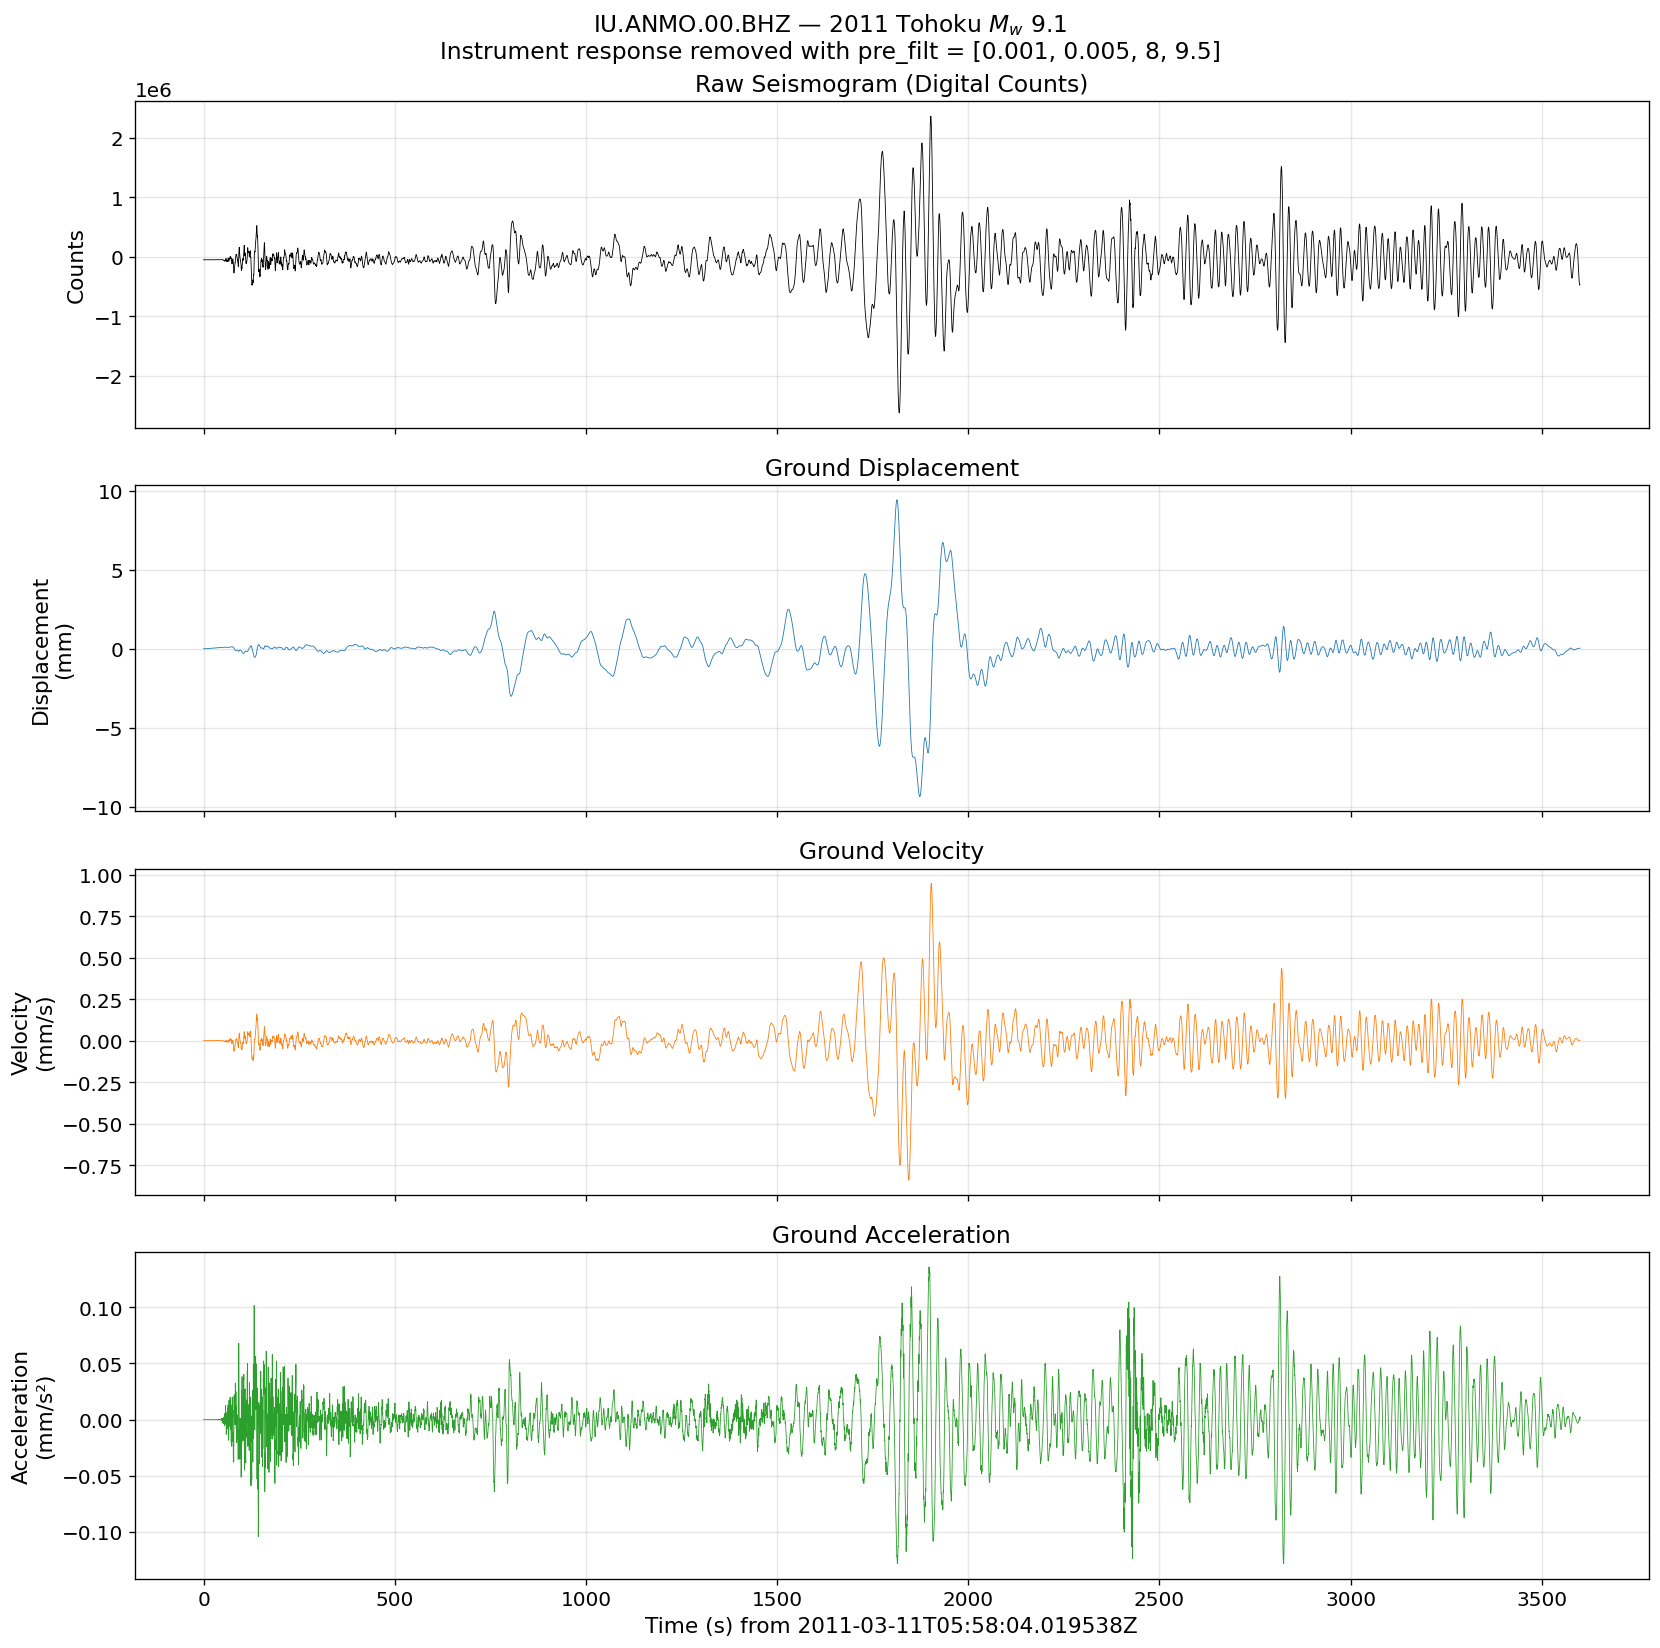

In [12]:
# Remove instrument response and recover ground motion in three forms

# Make copies — remove_response modifies in place
st_raw = st.copy()
st_disp = st.copy()
st_vel = st.copy()
st_acc = st.copy()

# Pre-filter: taper frequencies where response is very small
pre_filt = [0.001, 0.005, 8, 9.5]

st_disp.remove_response(inventory=inv, output="DISP", pre_filt=pre_filt)
st_vel.remove_response(inventory=inv, output="VEL", pre_filt=pre_filt)
st_acc.remove_response(inventory=inv, output="ACC", pre_filt=pre_filt)

# Plot comparison
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Raw counts
axes[0].plot(st_raw[0].times(), st_raw[0].data, 'k', linewidth=0.5)
axes[0].set_ylabel('Counts')
axes[0].set_title('Raw Seismogram (Digital Counts)')

# Displacement
axes[1].plot(st_disp[0].times(), st_disp[0].data * 1e3, 'C0', linewidth=0.5)
axes[1].set_ylabel('Displacement\n(mm)')
axes[1].set_title('Ground Displacement')

# Velocity
axes[2].plot(st_vel[0].times(), st_vel[0].data * 1e3, 'C1', linewidth=0.5)
axes[2].set_ylabel('Velocity\n(mm/s)')
axes[2].set_title('Ground Velocity')

# Acceleration
axes[3].plot(st_acc[0].times(), st_acc[0].data * 1e3, 'C2', linewidth=0.5)
axes[3].set_ylabel('Acceleration\n(mm/s²)')
axes[3].set_title('Ground Acceleration')

axes[3].set_xlabel(f'Time (s) from {st_raw[0].stats.starttime}')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle(f'IU.ANMO.00.BHZ — 2011 Tohoku $M_w$ 9.1\n'
             f'Instrument response removed with pre_filt = {pre_filt}',
             fontsize=14)
plt.tight_layout()
plt.show()


### Observations

Compare the four panels:

1. **Raw counts** — this is what the instrument actually records. The amplitude is in arbitrary "counts" determined by the digitizer gain. Without knowing the instrument response, these numbers are meaningless in physical units.

2. **Displacement** — shows the integrated ground motion. Notice the long-period surface waves (Rayleigh waves) with periods of ~20 s that dominate the displacement record.

3. **Velocity** — the most commonly used representation. Balanced view of both body waves (P, S arrivals) and surface waves.

4. **Acceleration** — emphasizes the highest-frequency content. Body wave arrivals appear sharpest here. This is what an accelerometer (strong-motion sensor) would record directly.

The relationship between these three is simply differentiation:
$$\text{Velocity} = \frac{d}{dt}(\text{Displacement}), \qquad \text{Acceleration} = \frac{d}{dt}(\text{Velocity})$$


## 2.3 Effect of Pre-filter Choice

The `pre_filt` parameter significantly affects the result. Let's compare different choices:


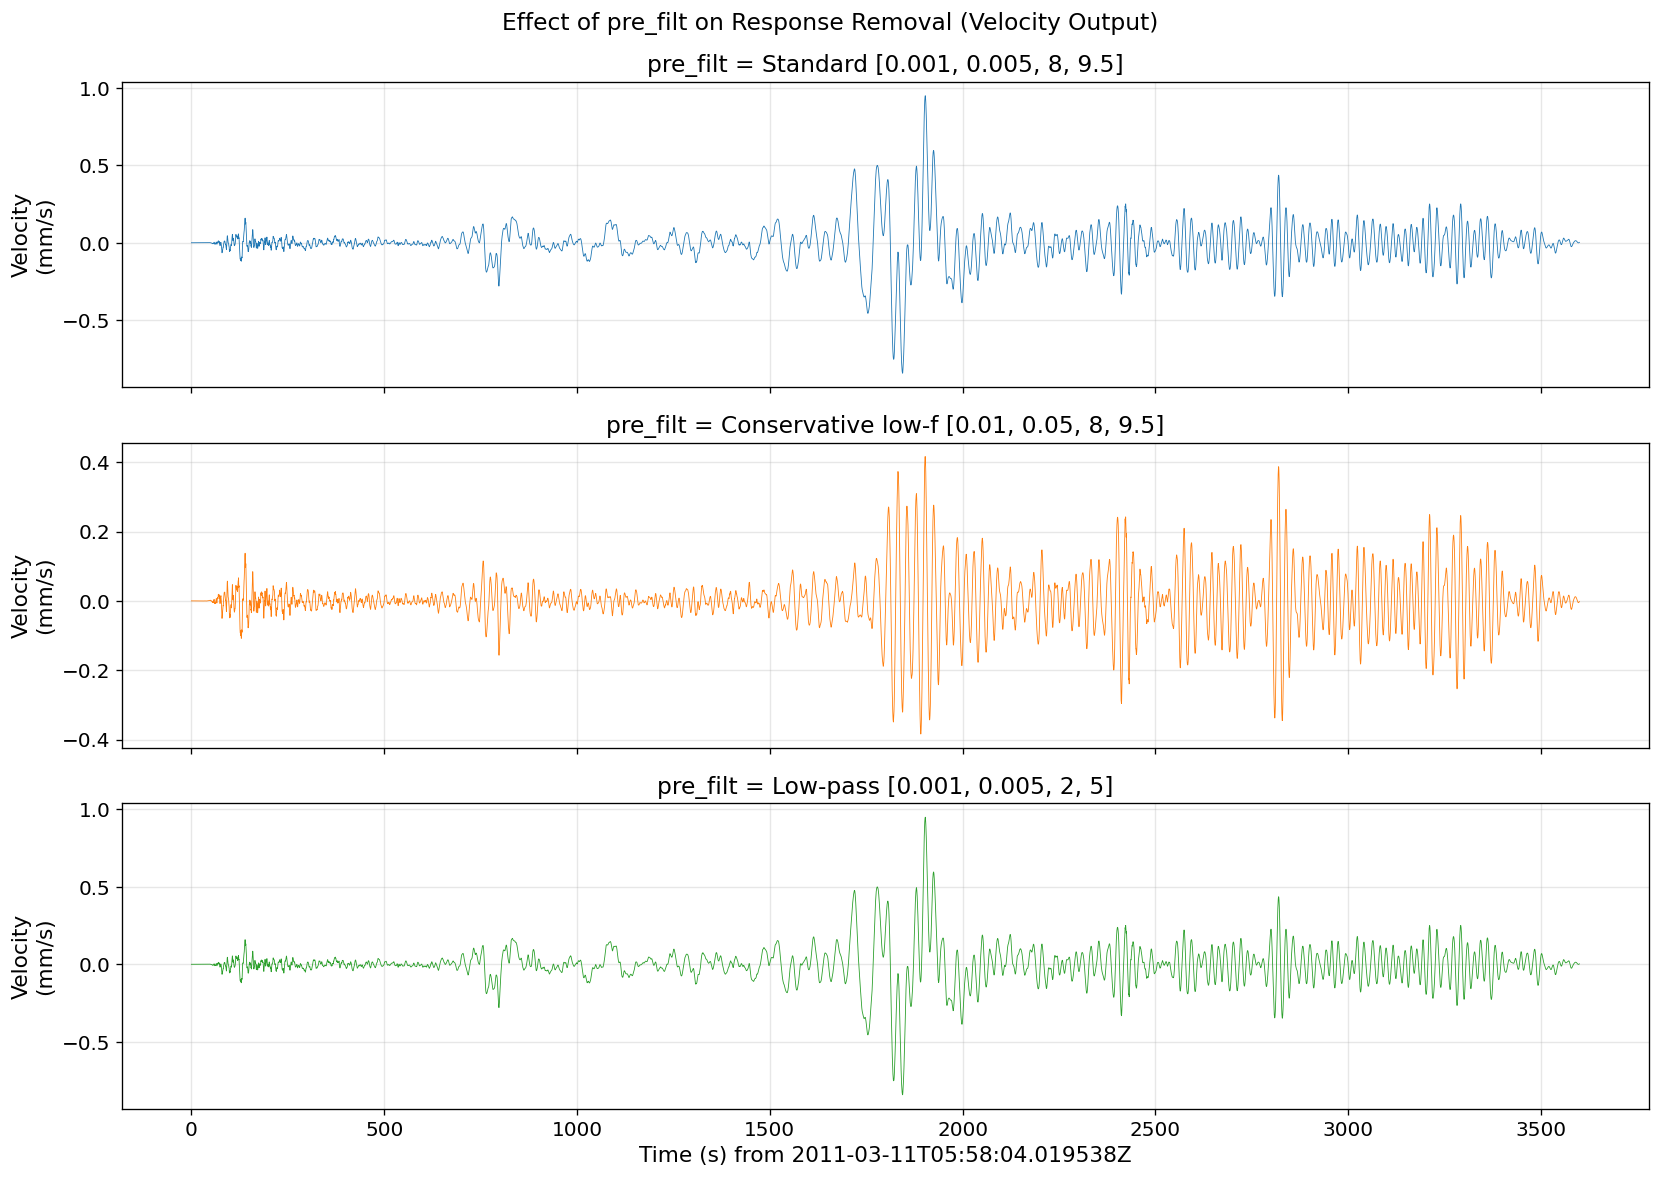

In [13]:
# Compare different pre_filt choices

pre_filts = [
    [0.001, 0.005, 8, 9.5],    # Standard (respecting Nyquist)
    [0.01, 0.05, 8, 9.5],      # More conservative low-frequency cutoff
    [0.001, 0.005, 2, 5],      # Aggressive high-frequency cutoff
]
labels = [
    'Standard [0.001, 0.005, 8, 9.5]',
    'Conservative low-f [0.01, 0.05, 8, 9.5]',
    'Low-pass [0.001, 0.005, 2, 5]',
]
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(len(pre_filts), 1, figsize=(14, 10), sharex=True)

for idx, (pf, label, color) in enumerate(zip(pre_filts, labels, colors)):
    st_tmp = st.copy()
    st_tmp.remove_response(inventory=inv, output="VEL", pre_filt=pf)

    axes[idx].plot(st_tmp[0].times(), st_tmp[0].data * 1e3, color=color, linewidth=0.5)
    axes[idx].set_ylabel('Velocity\n(mm/s)')
    axes[idx].set_title(f'pre_filt = {label}')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel(f'Time (s) from {st[0].stats.starttime}')

plt.suptitle('Effect of pre_filt on Response Removal (Velocity Output)', fontsize=14)
plt.tight_layout()
plt.show()


**Key takeaways on pre-filtering:**

- A more **conservative low-frequency cutoff** (middle panel) reduces long-period drift but may suppress real surface-wave signals
- A **low-pass pre-filter** (bottom panel) smooths out high-frequency noise and body-wave detail
- The standard choice (top panel) preserves the full bandwidth of the instrument

**Rule of thumb:** set `f1, f2` just below the sensor's low corner frequency, and `f3, f4` just below the Nyquist frequency (to avoid the region where the anti-alias filter attenuates the signal).


---
# Part 3: Beyond the Basics

## 3.1 A Brief History of Seismometers

| Era | Instrument | Key innovation |
|-----|-----------|---------------|
| 1880s | Milne horizontal pendulum | First systematic earthquake recording |
| 1900s | Wiechert inverted pendulum | Mechanical damping, ~1000 kg mass |
| 1910s | Galitzin electromagnetic | First electronic sensor — moving coil in magnetic field generates voltage proportional to velocity |
| 1960s | WWSSN (World-Wide Standardized Seismograph Network) | Global standardized network with calibrated responses |
| 1970s | Wielandt & Streckeisen STS-1 | Force-balance broadband — electronic feedback extends flat response to ultra-long periods (360 s) |
| 1990s | STS-2, Trillium | Compact broadband sensors enabling dense global networks (GSN, IRIS) |
| 2000s+ | MEMS accelerometers | Micro-machined silicon — enables smartphones and dense urban arrays |

The key breakthrough was **force-balance feedback**: instead of letting the mass swing freely, a feedback circuit applies a restoring force to keep the mass nearly stationary. The **feedback current** becomes the output signal. This effectively creates a sensor with an arbitrarily low "virtual" natural frequency while keeping the physical pendulum compact and stable.

## 3.2 Frontiers in Seismic Instrumentation

### Mars Seismology: InSight SEIS
The SEIS (Seismic Experiment for Interior Structure) instrument on NASA's InSight lander was the first broadband seismometer on another planet (2018–2022). Key challenges included extreme temperature variations, wind noise, and deploying a sensitive instrument robotically. SEIS detected hundreds of "marsquakes" and revealed Mars's internal structure for the first time.

> Lognonné, P., et al. (2019). SEIS: Insight's Seismic Experiment for Internal Structure of Mars. *Space Science Reviews*, 215, 12.
>
> Banerdt, W. B., et al. (2020). Initial results from the InSight mission on Mars. *Nature Geoscience*, 13, 183–189.

### Distributed Acoustic Sensing (DAS)
DAS turns ordinary **fiber-optic cables** into dense seismic arrays with meter-scale spacing over tens of kilometers. By sending laser pulses down a fiber and measuring backscattered light, DAS senses the **strain rate** along the cable. This has enabled seismology in previously inaccessible environments: ocean floors (using telecom cables), glaciers, volcanoes, and dense urban areas.

> Zhan, Z. (2020). Distributed Acoustic Sensing Turns Fiber‐Optic Cables into Sensitive Seismic Antennas. *Seismological Research Letters*, 91(1), 1–15.
>
> Lindsey, N. J., et al. (2017). Fiber‐Optic Network Observations of Earthquake Wavefields. *Geophysical Research Letters*, 44(23), 11792–11799.

### Rotational Seismology
Classical seismometers measure **translational** motion (3 components). But earthquakes also produce **rotational** ground motion. New ring laser gyroscopes and MEMS-based rotation sensors can measure all 6 degrees of freedom (3 translations + 3 rotations). This has applications in:
- Separating P and S waves without an array
- Measuring local site effects
- Improving earthquake early warning

> Igel, H., et al. (2021). ROMY: A Multicomponent Ring Laser for Geodesy and Geophysics. *Geophysical Journal International*, 225, 684–698.

### Smartphone Seismology
Modern smartphones contain MEMS accelerometers sensitive enough to detect moderate-to-large earthquakes. Projects like **MyShake** (UC Berkeley) have turned millions of smartphones into a global seismic network for earthquake early warning.

> Kong, Q., et al. (2016). MyShake: A smartphone seismic network for earthquake early warning and beyond. *Science Advances*, 2(2), e1501055.

## 3.3 Resources for Further Exploration

- **IRIS Education & Public Outreach**: [https://www.iris.edu/hq/inclass](https://www.iris.edu/hq/inclass)
- **ObsPy Documentation**: [https://docs.obspy.org](https://docs.obspy.org)
- **FDSN Station metadata**: [https://www.fdsn.org/networks/](https://www.fdsn.org/networks/)
- **IRIS Nominal Response Library**: lookup standard instrument responses
- Shearer, P. M. (2019). *Introduction to Seismology* (3rd ed.). Cambridge University Press. — Chapter 12 covers seismometers and instrument response.


---
# Exercises

1. **Transfer function analysis**: For a seismometer with $T_0 = 1$ s and $h = 0.7$, at what frequency does $|H(\omega)| = 0.5$? Find both the low-frequency and high-frequency crossing points.

2. **Damping design**: A seismometer has $\omega_0 = 2\pi$ rad/s. Plot the amplitude response for $h = 0.2, 0.5, 0.707, 1.0$. Which damping gives the flattest passband? Why is $h = 1/\sqrt{2}$ called "maximally flat"?

3. **Real data exploration**: Download data from a different station (e.g., `II.BFO` in Germany) for the same Tohoku earthquake. Compare the waveforms after response removal — are they consistent?

4. **Short-period vs. broadband**: Download both `BHZ` and `SHZ` (short-period) channels from the same station for the same event. Compare the raw and corrected waveforms. What information is lost in the short-period record?

5. **Sampling rate and Nyquist**: Download the `HHZ` channel (100 sps) from the same station and event. Compare its instrument response with `BHZ` (20 sps). How does the anti-alias filter change? At what frequency does the response drop off for each?
